<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK/blob/main/src/3_Technical_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initialization

In [17]:
from google.colab import drive
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy regionmask

drive.mount('/content/drive')
print("✅ Drive mounted successfully and environment initialization complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully and environment initialization complete!


In [18]:
# -*- coding: utf-8 -*-
import os
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Patch, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import geopandas as gpd
import matplotlib.gridspec as gridspec
from shapely.geometry import box
warnings.filterwarnings("ignore")

def plot_scatter(ax, df, x_name, y_name, title_name, x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\nInsufficient Data", fontsize=fontsize, fontweight='bold')
        return

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2


    ax.scatter(x, y, s=15, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.7, alpha=0.85, zorder=2)
    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.3
    v_min, v_max = d_min - pad, d_max + pad
    ax.set_xlim([v_min, v_max]); ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="#08519c", zorder=3)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)


    sign = "+" if intercept >= 0 else "-"
    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}')

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=fontsize-3,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='none'))

    ax.tick_params(axis='both', labelsize=fontsize-1, direction='out', length=4)

def plot_density_scatter(ax, df, x_name, y_name, title_name,
                         x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\nInsufficient Data",
                     fontsize=fontsize, fontweight='bold')
        return None, False

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2

    use_density = True
    try:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    except:
        use_density = False
        z = None

    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.4
    v_min, v_max = d_min - pad, d_max + pad

    ax.set_xlim([v_min, v_max])
    ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    if use_density:
        sc = ax.scatter(x, y, c=z, s=10, cmap='Spectral_r', edgecolor='none', alpha=0.85, zorder=2)
    else:
        sc = ax.scatter(x, y, s=15, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.4, alpha=0.85, zorder=2)


    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="black", zorder=3)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)


    sign = "+" if intercept >= 0 else "-"
    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}')

    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=fontsize-3,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.tick_params(axis='both', labelsize=fontsize-1, direction='out', length=4)

    return sc, use_density

SITE_META = {
    'BKT': 'Mountain Station',
    'HAT': 'Island Station',
    'YON': 'Island Station',
    'HKG': 'Urban Station',
    'HKO': 'Urban Station',
    'LLN': 'Mountain Station',
    'Hefei': 'Urban Station',
    'Burgos': 'Coastal Station'
}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR=Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK")

ground_obs_path= PROJECT_DIR / "data/ground_obs"
TCCON_path = PROJECT_DIR / "data/ground_obs/TCCON"
WDCGG_path= PROJECT_DIR / "data/ground_obs/WDCGG"

cams_path = PROJECT_DIR / "data/cams"
cams_nc = PROJECT_DIR / "data/cams/cams_xco2_month_2015_2024_resize.nc"

Validation_DIR=PROJECT_DIR / "output/Validation"
DOC_DIR= PROJECT_DIR / "docs"

stk_nc = PROJECT_DIR / "output/oco2_xco2_month_2015_2024_stk_SEA.nc"


# Process TCCON XCO2 observations for validation.

TCCON data source:Official TCCON Data Archive (https://tccondata.org/)
WDCGG data source:Official World Data Centre for Greenhouse Gases (https://gaw.kishou.go.jp/)
**Table 1.** Details of the TCCON and WDCGG observation sites utilized for evaluating reconstruction outcomes within the study area.

| Site   | Network | Lon (°E) | Lat (°N) | Elev. (m) |
|--------|---------|----------|----------|-----------|
| Hefei  | TCCON   | 117.17   | 31.90    | 35        |
| Burgos | TCCON   | 120.65   | 18.53    | 49        |
| BKT    | WDCGG   | 100.318  | -0.20194 | 864       |
| HKG    | WDCGG   | 114.258  | 22.2095  | 60        |
| HKO    | WDCGG   | 114.173  | 22.312   | 65        |
| LLN    | WDCGG   | 120.87   | 23.47    | 2862      |
| HAT    | WDCGG   | 123.809  | 24.0607  | 10        |


This script reads raw TCCON NetCDF files, converts observation times from UTC
to local time, selects observations acquired between 12:00 and 14:00 local time,
calculates monthly mean XCO2, and saves the processed results as CSV files for
subsequent validation against reconstructed XCO2 datasets.


In [19]:
import xarray as xr
import pandas as pd
from pathlib import Path

# =============================================================================
# 1. Paths
# =============================================================================
# Update this path according to the local directory containing the downloaded TCCON NetCDF files.
TCCON_RAW_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON")

SAVE_DIR = TCCON_path

# =============================================================================
# 2. Station information
# =============================================================================
STATIONS = {
    "hf": {
        "site_name": "Hefei",
        "utc_offset": 8
    },
    "bu": {
        "site_name": "Burgos",
        "utc_offset": 8
    }
}

FILES = [
    "hf20151102_20241229.public.qc.nc",
    "bu20170303_20231228.public.qc.nc"
]

# =============================================================================
# 3. Function to process a single TCCON file
# =============================================================================
def read_tccon_monthly(
    filepath: Path,
    site_name: str,
    utc_offset: int = 8,
    local_hour_start: int = 12,
    local_hour_end: int = 14
) -> pd.DataFrame:
    """
    Read a TCCON NetCDF file and calculate monthly mean XCO2.

    Parameters
    ----------
    filepath : Path
        Path to the input TCCON NetCDF file.
    site_name : str
        Name of the observation site.
    utc_offset : int, optional
        Time offset from UTC to local time, by default 8.
    local_hour_start : int, optional
        Start hour of the local-time filter (inclusive), by default 12.
    local_hour_end : int, optional
        End hour of the local-time filter (inclusive), by default 14.

    Returns
    -------
    pd.DataFrame
        Monthly mean XCO2 data with columns:
        ['time', 'XCO2', 'site', 'lat', 'lon'].
        Returns an empty DataFrame if the input file is invalid or missing.
    """
    empty_df = pd.DataFrame(columns=["time", "XCO2", "site", "lat", "lon"])

    if not filepath.exists():
        print(f"Warning: file not found: {filepath}")
        return empty_df

    try:
        with xr.open_dataset(filepath, decode_timedelta=False) as ds:
            # -----------------------------------------------------------------
            # Check required variables
            # -----------------------------------------------------------------
            if "time" not in ds.variables:
                print(f"Warning: 'time' variable not found in {filepath.name}")
                return empty_df

            if "xco2" not in ds.variables:
                print(f"Warning: 'xco2' variable not found in {filepath.name}")
                return empty_df

            # -----------------------------------------------------------------
            # Read coordinates
            # TCCON files may use 'long' instead of 'lon'
            # -----------------------------------------------------------------
            if "lat" not in ds.variables:
                print(f"Warning: 'lat' variable not found in {filepath.name}")
                return empty_df

            if "long" in ds.variables:
                lon_var = ds["long"]
            elif "lon" in ds.variables:
                lon_var = ds["lon"]
            else:
                print(f"Warning: longitude variable not found in {filepath.name}")
                return empty_df

            lat_var = ds["lat"]

            lat = float(lat_var.values[0]) if lat_var.ndim > 0 else float(lat_var.values)
            lon = float(lon_var.values[0]) if lon_var.ndim > 0 else float(lon_var.values)

            # -----------------------------------------------------------------
            # Build DataFrame
            # -----------------------------------------------------------------
            df = pd.DataFrame({
                "time_utc": pd.to_datetime(ds["time"].values),
                "xco2": ds["xco2"].values.reshape(-1)
            })

        # Remove missing values
        df = df.dropna(subset=["time_utc", "xco2"])

        if df.empty:
            print(f"Warning: no valid observations in {filepath.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Convert UTC to local time
        # ---------------------------------------------------------------------
        df["time_local"] = df["time_utc"] + pd.Timedelta(hours=utc_offset)

        # ---------------------------------------------------------------------
        # Select observations acquired between 12:00 and 14:00 local time
        # to improve temporal consistency with satellite overpass conditions.
        # ---------------------------------------------------------------------
        df = df[
            (df["time_local"].dt.hour >= local_hour_start) &
            (df["time_local"].dt.hour <= local_hour_end)
        ].copy()

        if df.empty:
            print(
                f"Warning: no observations within local time "
                f"{local_hour_start:02d}:00-{local_hour_end:02d}:59 in {filepath.name}"
            )
            return empty_df

        # ---------------------------------------------------------------------
        # Aggregate filtered observations to monthly mean values.
        # Monthly grouping is based on local time.
        # ---------------------------------------------------------------------
        df_monthly = (
            df.resample("ME", on="time_local")["xco2"]
            .mean()
            .reset_index()
            .rename(columns={
                "time_local": "time",
                "xco2": "XCO2"
            })
        )

        # Add site metadata
        df_monthly["site"] = site_name
        df_monthly["lat"] = lat
        df_monthly["lon"] = lon

        # Reorder columns
        df_monthly = df_monthly[["time", "XCO2", "site", "lat", "lon"]]

        # Sort by time
        df_monthly = df_monthly.sort_values("time").reset_index(drop=True)

        return df_monthly

    except Exception as e:
        print(f"Error while processing {filepath.name}: {e}")
        return empty_df


# =============================================================================
# 4. Main processing loop
# =============================================================================
all_sites_data = []

for filename in FILES:
    station_code = filename[:2]

    if station_code not in STATIONS:
        print(f"Warning: unknown station code in file name: {filename}")
        continue

    site_name = STATIONS[station_code]["site_name"]
    utc_offset = STATIONS[station_code]["utc_offset"]

    input_file = TCCON_RAW_PATH / filename

    df_monthly = read_tccon_monthly(
        filepath=input_file,
        site_name=site_name,
        utc_offset=utc_offset,
        local_hour_start=12,
        local_hour_end=14
    )

    if not df_monthly.empty:
        output_file = SAVE_DIR / f"TCCON_{site_name}_12-14h_monthly.csv"
        df_monthly.to_csv(output_file, index=False, encoding="utf-8-sig")
        all_sites_data.append(df_monthly)
        print(f"Saved: {site_name} -> {output_file}")

# =============================================================================
# 5. Save combined CSV file
# =============================================================================
if all_sites_data:
    df_all = pd.concat(all_sites_data, ignore_index=True)
    combined_output = ground_obs_path  / "TCCON_all_sites_12-14h_monthly.csv"
    df_all.to_csv(combined_output, index=False, encoding="utf-8-sig")
    print(f"Saved combined file -> {combined_output}")
else:
    print("No valid monthly TCCON data were generated.")

Saved: Hefei -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON/TCCON_Hefei_12-14h_monthly.csv
Saved: Burgos -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON/TCCON_Burgos_12-14h_monthly.csv
Saved combined file -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON_all_sites_12-14h_monthly.csv


# Process monthly WDCGG CO2 NetCDF files for validation.

In [20]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# =============================================================================
# 1. Paths and settings
# =============================================================================
# Update this path to the directory containing the downloaded WDCGG monthly NetCDF files.
WDCGG_RAW_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly")
SAVE_DIR = WDCGG_path
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DATA_TYPE = "month"

# Target validation sites
TARGET_SITES = ["BKT", "HAT", "HKG", "HKO", "LLN", "YON"]

# =============================================================================
# 2. Function for reading a single WDCGG monthly file
# =============================================================================
def read_wdcgg_monthly_nc(file_path: Path) -> pd.DataFrame:
    """
    Read a monthly WDCGG NetCDF file and convert it to a standardized DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to the input WDCGG monthly NetCDF file.

    Returns
    -------
    pd.DataFrame
        A standardized DataFrame with columns:
        ['time', 'co2', 'site', 'lat', 'lon'].
        Returns an empty DataFrame if no valid data are available.
    """
    empty_df = pd.DataFrame(columns=["time", "co2", "site", "lat", "lon"])

    if not file_path.exists():
        print(f"Warning: file not found: {file_path}")
        return empty_df

    ds = None
    try:
        # Open without automatic time decoding to avoid errors caused by
        # non-standard units such as "months since ..."
        ds = xr.open_dataset(file_path, decode_times=False)

        if "time" not in ds.variables:
            print(f"Warning: 'time' variable not found in {file_path.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Parse time information
        # ---------------------------------------------------------------------
        units = ds.time.attrs.get("units", "")

        if "months since" in units:
            base_date_str = units.split("since ")[1].split(" +")[0].strip()
            base_date = pd.to_datetime(base_date_str)
            times = [base_date + pd.DateOffset(months=int(m)) for m in ds.time.values]
        else:
            ds_decoded = xr.decode_cf(ds)
            times = pd.to_datetime(ds_decoded.time.values)

        # ---------------------------------------------------------------------
        # Identify the CO2 variable name
        # Different WDCGG products may use different variable names
        # ---------------------------------------------------------------------
        candidate_vars = ["value", "co2", "parameter_value"]
        var_name = next((var for var in candidate_vars if var in ds.data_vars), None)

        if var_name is None:
            print(f"Warning: no CO2 variable found in {file_path.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Extract site metadata
        # ---------------------------------------------------------------------
        lat = float(np.atleast_1d(ds.attrs.get("latitude", ds.get("latitude", 0)))[0])
        lon = float(np.atleast_1d(ds.attrs.get("longitude", ds.get("longitude", 0)))[0])

        default_site_id = Path(file_path).stem.split("_")[1].upper()
        site_id = ds.attrs.get("site_code", default_site_id).upper()

        # ---------------------------------------------------------------------
        # Construct DataFrame
        # ---------------------------------------------------------------------
        df = pd.DataFrame({
            "time": times,
            "co2": ds[var_name].values.reshape(-1)
        })

        # Remove timezone information if present
        df["time"] = pd.to_datetime(df["time"]).dt.tz_localize(None)

        # Standardize timestamps to monthly scale for comparison with monthly
        # satellite or reconstructed products
        df["time"] = df["time"].dt.to_period("M").dt.to_timestamp()

        # Remove missing and clearly invalid values
        # WDCGG fill values are often extremely large (e.g., ~9.9e33)
        df = df.dropna(subset=["time", "co2"])
        df = df[(df["co2"] > 300) & (df["co2"] < 600)].copy()

        if df.empty:
            return empty_df

        # Add metadata
        df["site"] = site_id
        df["lat"] = lat
        df["lon"] = lon

        # Reorder columns
        df = df[["time", "co2", "site", "lat", "lon"]].reset_index(drop=True)

        return df

    except Exception as e:
        print(f"Error while processing {file_path.name}: {e}")
        return empty_df

    finally:
        if ds is not None:
            ds.close()


# =============================================================================
# 3. Batch processing
# =============================================================================
print(f"Starting WDCGG processing for sites: {TARGET_SITES}")

files = sorted(WDCGG_RAW_PATH.glob(f"co2_*_surface*_{DATA_TYPE}*.nc"))

processed_count = 0

for file_path in files:
    # Skip auxiliary meteorological files
    if "_met.nc" in file_path.name:
        continue

    try:
        raw_site_id = file_path.name.split("_")[1].upper()
        site_id = "".join(filter(str.isalpha, raw_site_id))
    except IndexError:
        print(f"Warning: unexpected file name format: {file_path.name}")
        continue

    if site_id not in TARGET_SITES:
        continue

    try:
        df_site = read_wdcgg_monthly_nc(file_path)

        if not df_site.empty:
            site_type = file_path.name.split("_")[2]
            output_file = SAVE_DIR / f"WDCGG_{site_id}_{site_type}_{DATA_TYPE}.csv"
            df_site.to_csv(output_file, index=False, encoding="utf-8-sig")
            processed_count += 1
            print(f"Saved: {output_file.name} ({len(df_site)} records)")
        else:
            print(f"Warning: no valid data extracted from {file_path.name}")

    except Exception as e:
        print(f"Failed to process {file_path}: {e}")

print(f"\nCompleted. {processed_count} site file(s) were successfully processed.")


OUT_FILE = ground_obs_path  / "WDCGG_all_sites_monthly.csv"
exclude_files = {"WDCGG_BKT_surface-insitu_month.csv"}

csv_files = [
    f for f in sorted(WDCGG_path.glob("*.csv"))
    if f.name not in exclude_files
]

if not csv_files:
    print("No CSV files found for merging.")
else:
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
            print(f"Read: {file.name} ({len(df)} rows)")
        except Exception as e:
            print(f"Failed to read: {file.name}, error: {e}")

    if df_list:
        df_all = pd.concat(df_list, ignore_index=True)
        df_all.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
        print(f"\nMerge complete: {OUT_FILE}")
        print(f"Total records: {len(df_all)}")


Starting WDCGG processing for sites: ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']
Saved: WDCGG_BKT_surface-flask_month.csv (230 records)
Saved: WDCGG_BKT_surface-insitu_month.csv (102 records)
Saved: WDCGG_HAT_surface-insitu_month.csv (378 records)
Saved: WDCGG_HKG_surface-insitu_month.csv (176 records)
Saved: WDCGG_HKO_surface-insitu_month.csv (185 records)
Saved: WDCGG_LLN_surface-flask_month.csv (219 records)
Saved: WDCGG_YON_surface-insitu_month.csv (326 records)

Completed. 7 site file(s) were successfully processed.
Read: WDCGG_BKT_surface-flask_month.csv (230 rows)
Read: WDCGG_HAT_surface-insitu_month.csv (378 rows)
Read: WDCGG_HKG_surface-insitu_month.csv (176 rows)
Read: WDCGG_HKO_surface-insitu_month.csv (185 rows)
Read: WDCGG_LLN_surface-flask_month.csv (219 rows)
Read: WDCGG_YON_surface-insitu_month.csv (326 rows)

Merge complete: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/WDCGG_all_sites_monthly.csv
Total records: 1514


#Spatio-temporal matching between ground-based observations and reconstructed datasets

In [21]:
import math
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_squared_error

def map_site_match(site_df, da,da_name):
    if (da.lon > 180).any():
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby('lon')

    all_results = []
    sites = site_df['site'].unique()

    for site in sites:
        sub_df = site_df[site_df['site'] == site].copy()
        lat, lon = sub_df['lat'].iloc[0], sub_df['lon'].iloc[0]

        try:
            point_da = da.sel(lat=lat, lon=lon, method='nearest')
            df_sat = point_da.to_dataframe().reset_index()

            # Ensure time column name consistency
            sat_val_col = [c for c in df_sat.columns if c not in ['lat', 'lon', 'time']][0]
            df_sat = df_sat[['time', sat_val_col]].rename(columns={sat_val_col: da_name})

            sub_df['time_period'] = sub_df['time'].dt.to_period('M')
            df_sat['time_period'] = pd.to_datetime(df_sat['time']).dt.to_period('M')

            merged = pd.merge(sub_df, df_sat, on='time_period', suffixes=('', '_grid'), how='inner').dropna()
            if not merged.empty:
                all_results.append(merged)
        except:
            continue

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()


for map_name in ["cams","stk"]:
  map_nc=stk_nc
  if map_name == "cams":
    map_nc=cams_nc


  map_ds = xr.open_dataset(map_nc)
  map_da = map_ds['xco2']

  files = ["TCCON_all_sites_12-14h_monthly.csv", "WDCGG_all_sites_monthly.csv"]
  for file in files:
      # Extract source name (e.g., 'TCCON' or 'WDCGG')
      prefix = file.split("_")[0]
      csv_fn = ground_obs_path / file

      if not csv_fn.exists():
          print(f"File not found: {file}")
          continue

      df_obs = pd.read_csv(csv_fn, parse_dates=['time'])
      matched_df = map_site_match(df_obs, map_da,map_name)

      if not matched_df.empty:
          # Construct output path using the prefix
          output_csv = Validation_DIR / f"matched_{map_name}_{prefix.lower()}.csv"

          # Ensure the output directory exists
          Validation_DIR.mkdir(parents=True, exist_ok=True)
          matched_df = matched_df.drop(
              columns=["time_period", "time_grid"]
              )
          matched_df.to_csv(output_csv, index=False)
          print(f"Saved {prefix} results to: {output_csv}")

  map_da.close()

Saved TCCON results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_cams_tccon.csv
Saved WDCGG results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_cams_wdcgg.csv
Saved TCCON results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_stk_tccon.csv
Saved WDCGG results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_stk_wdcgg.csv


#Comparative Accuracy Assessment of CAMS and STK Reconstructed Data Based on TCCON Ground XCO$_2$ Observations

Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/docs/validation_tccon_cams_stk.png


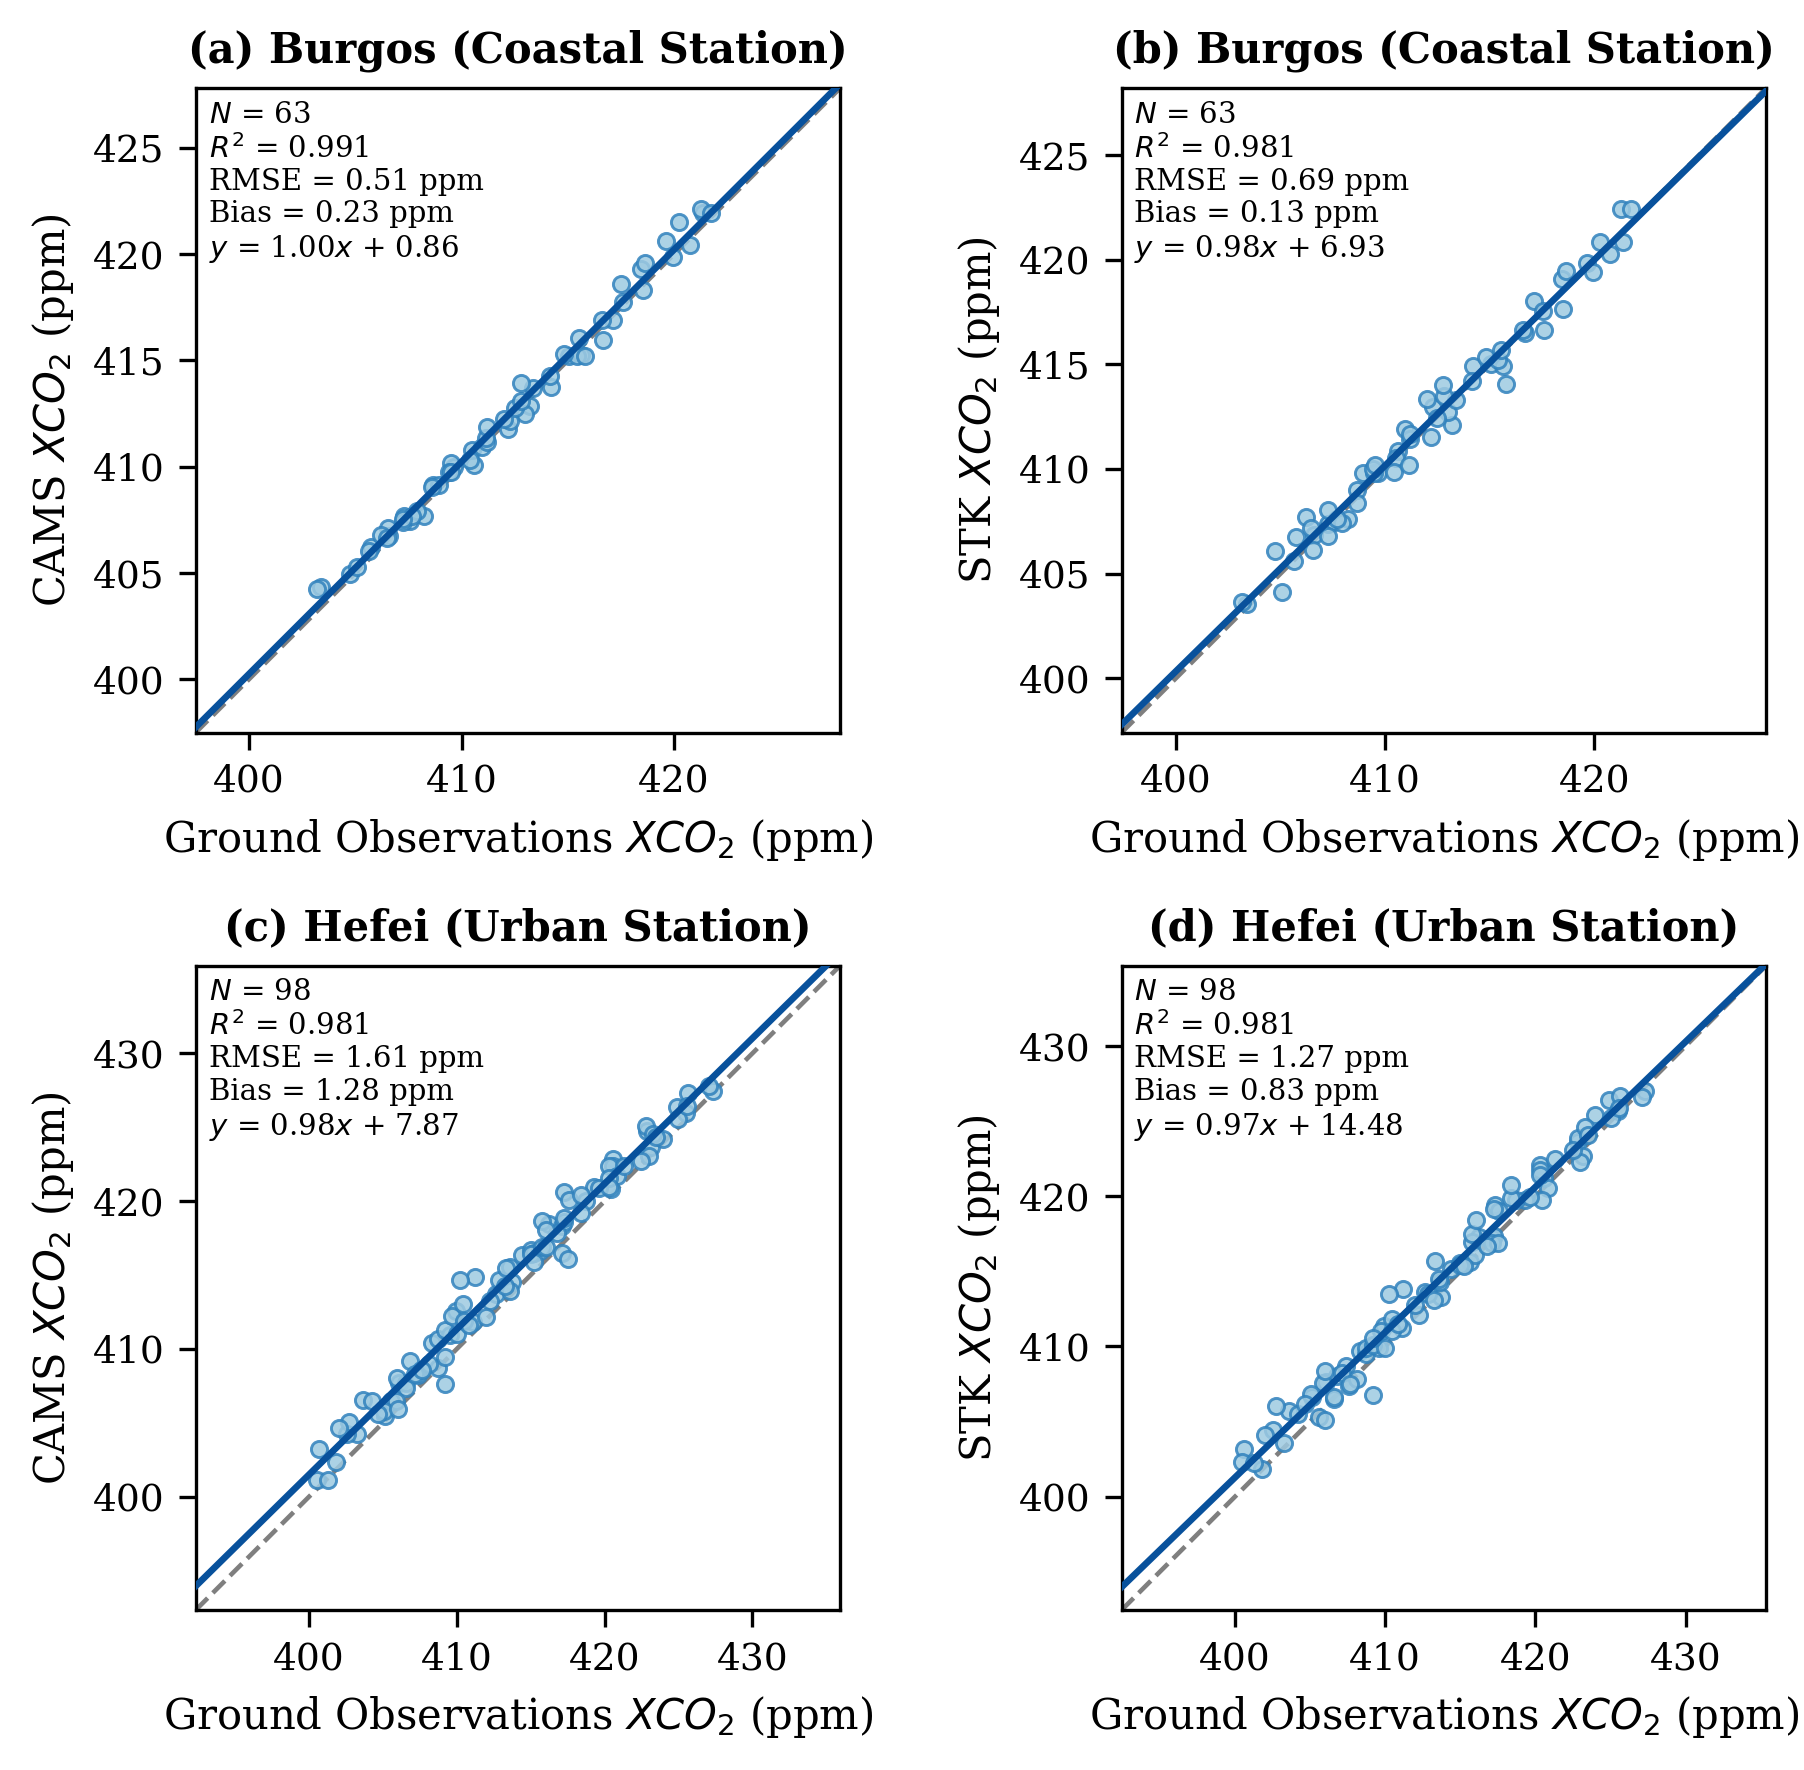

In [22]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

cams_fn = Validation_DIR / "matched_cams_tccon.csv"
stk_fn  = Validation_DIR / "matched_stk_tccon.csv"

df_cams = pd.read_csv(cams_fn)
df_stk  = pd.read_csv(stk_fn)


sites_cams = set(df_cams["site"].dropna().unique())
sites_stk  = set(df_stk["site"].dropna().unique())
common_sites = sorted(sites_cams & sites_stk)

if len(common_sites) == 0:
    raise ValueError("No common sites found between CAMS and STK data, cannot plot pairwise.")

sites_to_plot = common_sites[:2]


n_rows = len(sites_to_plot)
n_cols = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3 * n_rows),
    dpi=300
)

if n_rows == 1:
    axes = [axes]

def find_ground_col(df):
    potential_cols = ["xco2", "co2", "co2_ppm"]
    cols_lower = {c.lower(): c for c in df.columns}
    for col in potential_cols:
        if col in cols_lower:
            return cols_lower[col]
    return None


panel_idx = 0
map_info = [("cams", df_cams), ("stk", df_stk)]

for i, site in enumerate(sites_to_plot):
    for j, (map_name, df_map) in enumerate(map_info):
        ax = axes[i][j] if n_rows > 1 else axes[j]

        sub = df_map[df_map["site"] == site].copy()
        x_col = find_ground_col(sub)

        if sub.empty:
            ax.text(0.5, 0.5, f"No data for\n{site}",
                    ha="center", va="center", fontsize=10)
            ax.set_axis_off()
            panel_idx += 1
            continue

        if x_col is None:
            ax.text(0.5, 0.5, f"No ground XCO$_2$/CO$_2$\ncolumn in {site}",
                    ha="center", va="center", fontsize=10)
            ax.set_axis_off()
            panel_idx += 1
            continue

        display_label = "$XCO_2$" if "xco2" in x_col.lower() else "$CO_2$"

        plot_scatter(
            ax=ax,
            df=sub,
            x_name=x_col,
            y_name=map_name,
            title_name=f"{site} ({SITE_META.get(site, 'Station')})",
            x_label=f"Ground Observations {display_label} (ppm)",
            y_label=f"{map_name.upper()} $XCO_2$ (ppm)",
            sublabel=chr(97 + panel_idx)   # a, b, c, d
        )

        panel_idx += 1


plt.tight_layout()
png_fn = DOC_DIR / "validation_tccon_cams_stk.png"
plt.savefig(png_fn, bbox_inches="tight")
print(f"Saved: {png_fn}")
plt.show()

# Temporal Consistency Analysis of CAMS, STK-Reconstructed XCO$_2$, and WDCGG Observations




To evaluate the ability of the CAMS background field and the STK-reconstructed dataset to represent regional background CO$_2$ temporal variability, paired CAMS–WDCGG and STK–WDCGG datasets were read and merged using the `time` and `site` fields. Site-specific time series of WDCGG CO$_2$ observations, CAMS XCO$_2$, and STK-reconstructed XCO$_2$ were then plotted, and the Pearson correlation coefficients ($R$) between CAMS and WDCGG, as well as between STK and WDCGG, were calculated separately. This analysis was primarily intended to assess the consistency of temporal variations captured by different datasets relative to site observations. Since WDCGG reflects near-surface CO$_2$ concentrations, whereas CAMS and STK represent column-averaged dry-air mole fractions of CO$_2$ (XCO$_2$), the two are not directly comparable in terms of observation level and physical meaning. Therefore, this comparison focuses on temporal consistency rather than one-to-one agreement in absolute concentration values.

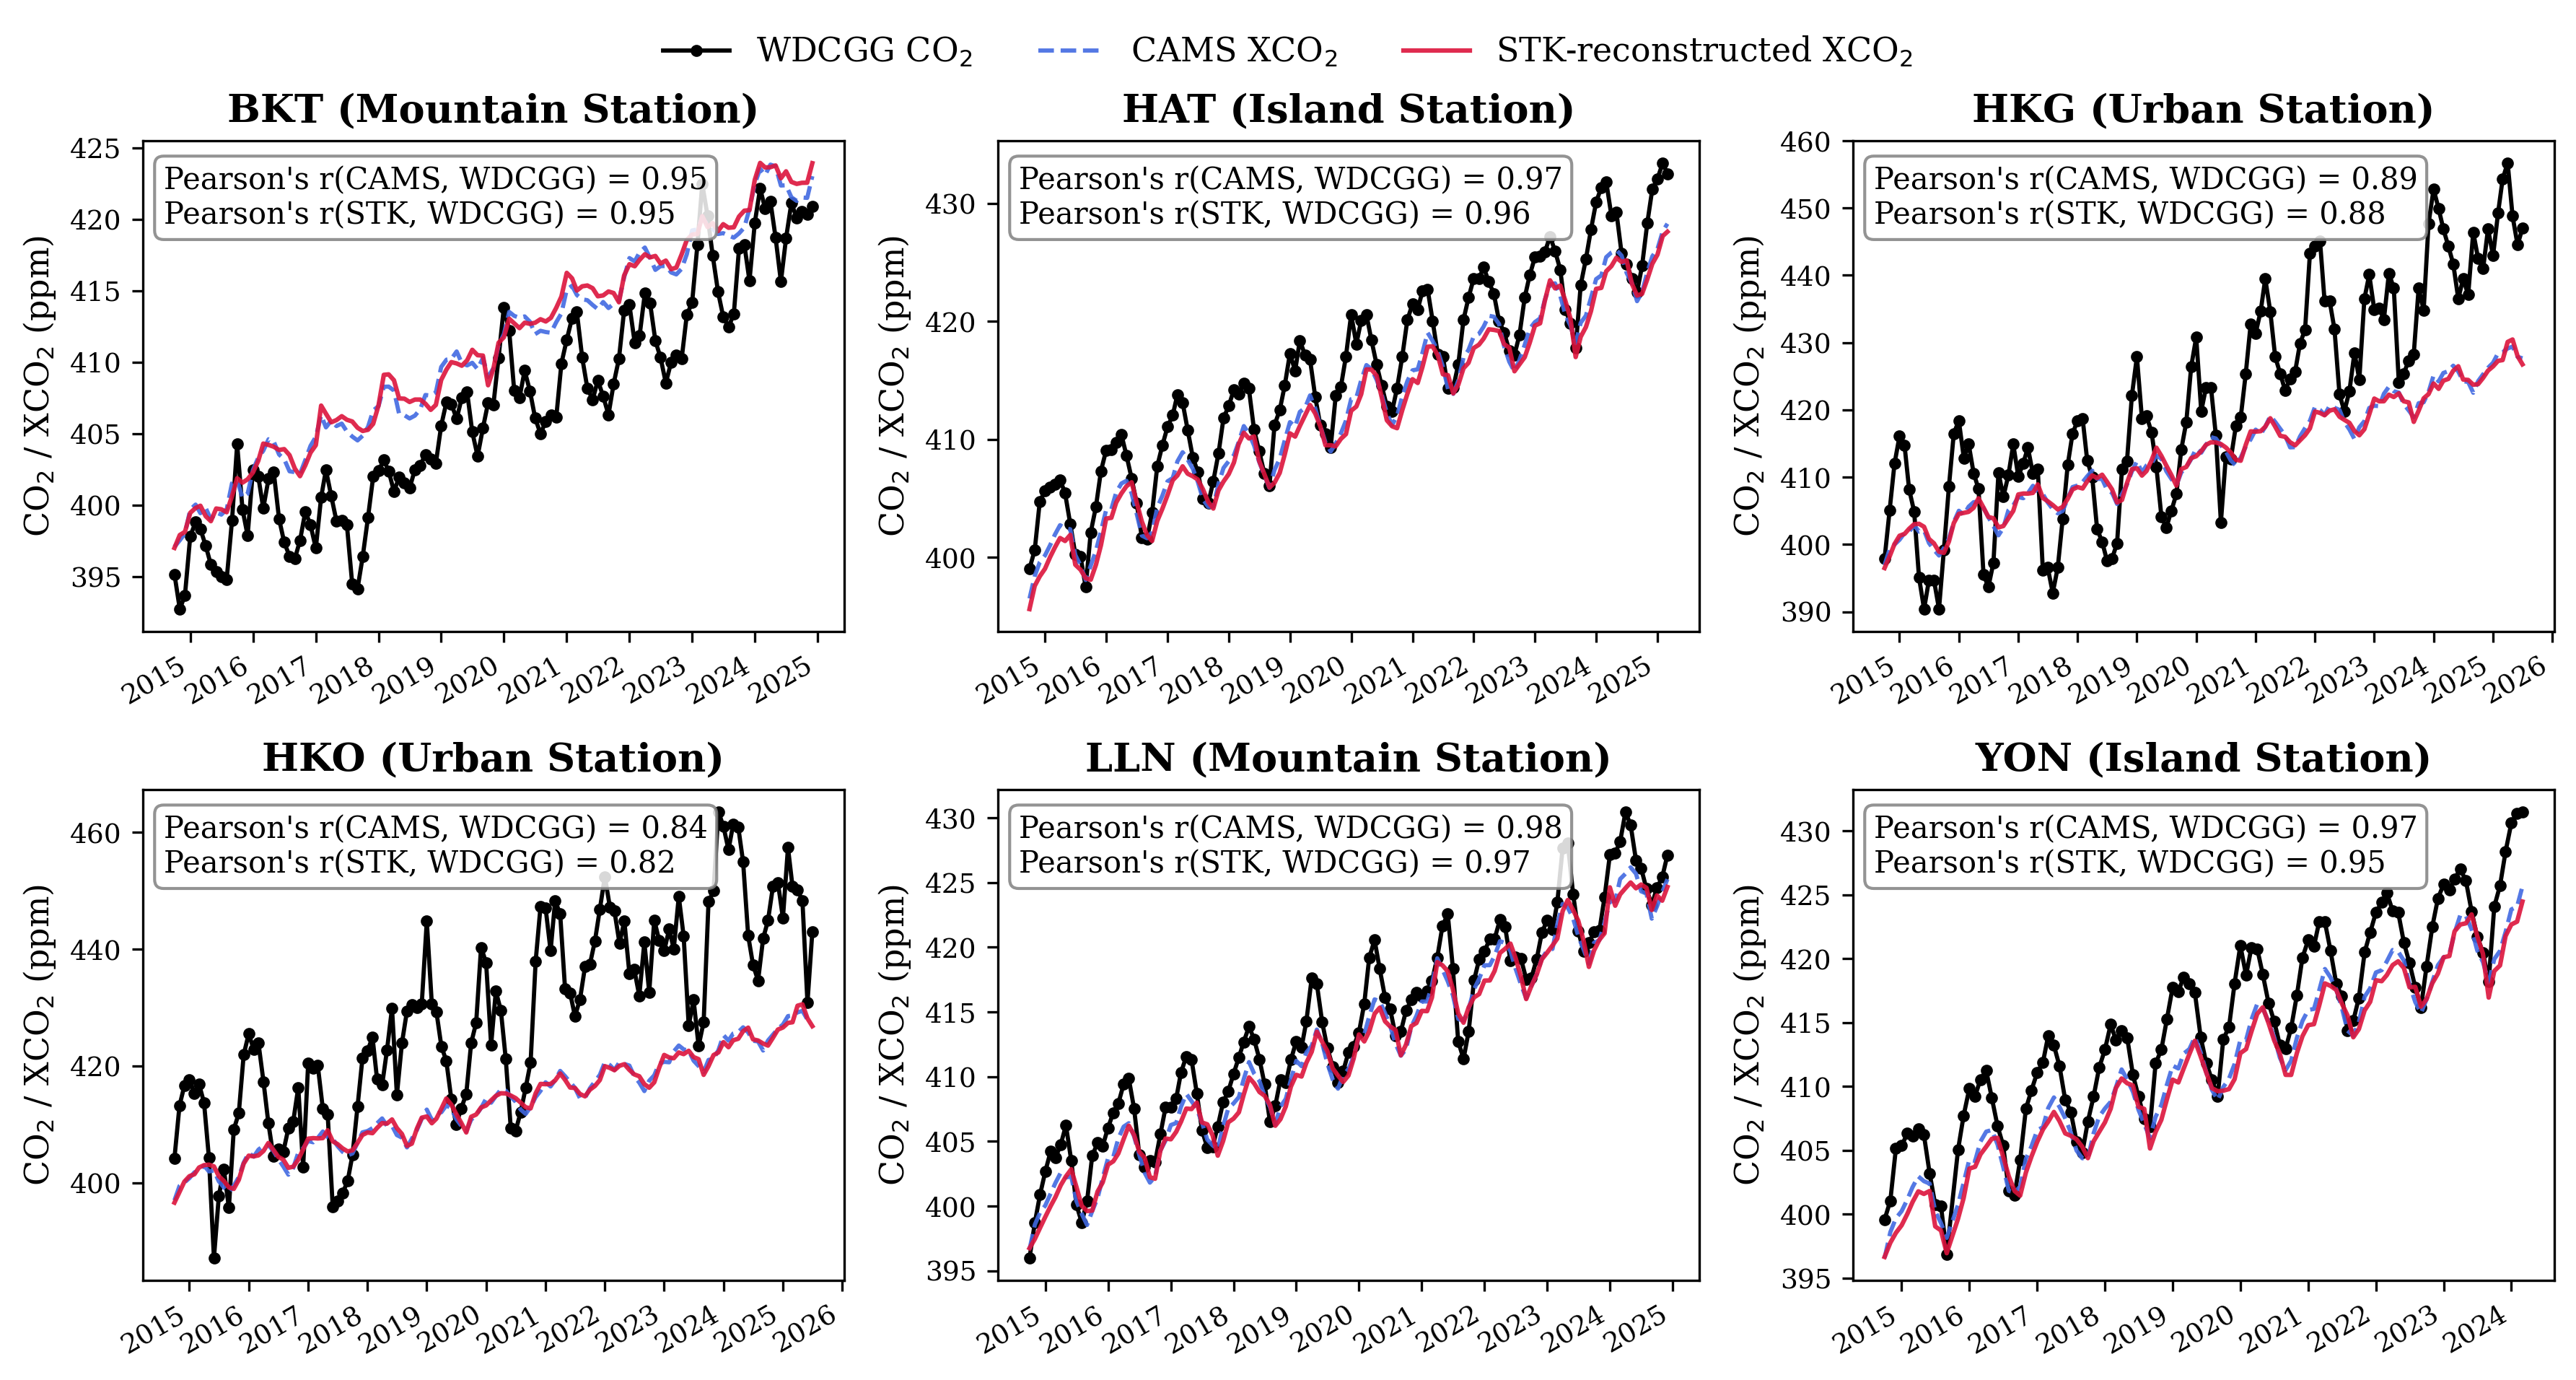

In [23]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# =========================
# 1. Read data
# =========================
cams_df = pd.read_csv(Validation_DIR / "matched_cams_wdcgg.csv")
stk_df = pd.read_csv(Validation_DIR / "matched_stk_wdcgg.csv")

cams_df["time"] = pd.to_datetime(cams_df["time"])
stk_df["time"] = pd.to_datetime(stk_df["time"])

# =========================
# 2. Merge data
# =========================
comparison_df = pd.merge(
    cams_df,
    stk_df,
    on=["time", "site"],
    suffixes=("_cams", "_stk")
)

# Select and rename columns
df = comparison_df[["time", "site", "co2_cams", "cams", "stk"]].copy()
df.columns = ["time", "site", "co2", "cams", "stk"]

sites = sorted(df["site"].unique())
n_sites = len(sites)

# =========================
# 3. Figure layout
# =========================
n_cols = 3
n_rows = math.ceil(n_sites / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4*n_cols, 3.2 * n_rows),
    sharex=False,
    sharey=False,
    dpi=300
)

if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# =========================
# 4. Plot each site
# =========================
for i, site in enumerate(sites):
    ax = axes[i]
    site_data = df[df["site"] == site].sort_values("time").copy()

    if site_data.empty:
        ax.axis("off")
        continue

    # Drop NaNs separately for correlation calculation
    valid_cams = site_data[["co2", "cams"]].dropna()
    valid_stk  = site_data[["co2", "stk"]].dropna()

    r_cams = valid_cams["co2"].corr(valid_cams["cams"]) if len(valid_cams) > 1 else float("nan")
    r_stk  = valid_stk["co2"].corr(valid_stk["stk"]) if len(valid_stk) > 1 else float("nan")

    # Plot lines
    ax.plot(
        site_data["time"], site_data["co2"],
        label="WDCGG CO$_2$",
        color="black",
        linewidth=1.4,
        marker="o",
        markersize=3
    )

    ax.plot(
        site_data["time"], site_data["cams"],
        label="CAMS XCO$_2$",
        color="royalblue",
        linewidth=1.4,
        linestyle="--",
        alpha=0.9
    )

    ax.plot(
        site_data["time"], site_data["stk"],
        label="STK-reconstructed XCO$_2$",
        color="crimson",
        linewidth=1.5,
        linestyle="-",
        alpha=0.9
    )

    # Title and labels
    clean_site = re.sub(r'\d+', '', str(site)).strip()
    info = SITE_META.get(clean_site)
    if info:
        title_text = f"{clean_site} ({info})"
    else:
        title_text = clean_site
    ax.set_title(title_text, fontsize=13, fontweight="bold")
    ax.set_ylabel("CO$_2$ / XCO$_2$ (ppm)", fontsize=11)

    # Grid

    # Time axis
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

    # Annotation of correlation coefficients
    ax.text(
        0.03, 0.95,
        f"Pearson's r(CAMS, WDCGG) = {r_cams:.2f}\nPearson's r(STK, WDCGG) = {r_stk:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.85)
    )

# =========================
# 5. Hide unused subplots
# =========================
for j in range(n_sites, len(axes)):
    axes[j].axis("off")

# =========================
# 6. Shared legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, 1.0)
)

# =========================
# 7. Layout
# =========================
fig.tight_layout(rect=[0, 0, 1, 0.96])
png_fn=DOC_DIR / "validation_wdgcc_cams_stk.png"
plt.savefig(png_fn, bbox_inches='tight')
plt.show()

#Independent cross-validation using processed OCO-3 monthly XCO2 data

OCO-3 monthly XCO2 data, processed using the same quality control, gridding, monthly adjustment procedures as OCO-2, were used as an independent
dataset for cross-validation of the reconstructed XCO2 product.

stk (Matching reconstructed data with OCO-3): Saved as matched_stk_oco3.csv
cams (Matching cams data with OCO-3): Saved as matched_cams_oco3.csv
daily (Matching gridded daily OCO-2 and OCO-3): Saved as matched_oco2_oco3_daily.csv

month (Matching monthly OCO-2 and OCO-3 processed via the Keeling curve): Saved as matched_oco2_oco3_month.csv

In [24]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

for match_name in ["daily", "month", "stk","cams"]:
    if match_name == "stk":
        ref_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        test_path = PROJECT_DIR / "output/oco2_xco2_month_2015_2024_stk_SEA.nc"
        matched_csv = Validation_DIR / f"matched_stk_oco3.csv"
        ref_name = "oco3"
        test_name="stk"
    elif match_name == "daily":
        ref_path = PROJECT_DIR / "data/Satellite/step02_grid/oco2_xco2_daily_201409_202512.nc"
        test_path = PROJECT_DIR / "data/Satellite/step02_grid/oco3_xco2_daily_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_oco2_oco3_daily.csv"
        ref_name = "oco2"
        test_name="oco3"
    elif match_name == "month":
        ref_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco2_xco2_month_201409_202512.nc"
        test_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_oco2_oco3_month.csv"
        ref_name = "oco2"
        test_name="oco3"
    elif match_name == "cams":
        ref_path = PROJECT_DIR / "data/cams/cams_xco2_month_2015_2024_resize.nc"
        test_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_cams_oco3_month.csv"
        ref_name = "cams"
        test_name="oco3"

    ds_ref = xr.open_dataset(ref_path)
    ds_test = xr.open_dataset(test_path)

    if 'time' in ds_ref.dims:
        ds_ref = ds_ref.drop_duplicates(dim='time')
    if 'time' in ds_test.dims:
        ds_test = ds_test.drop_duplicates(dim='time')

    start_time = max(ds_ref.time.min(), ds_test.time.min())
    end_time = min(ds_ref.time.max(), ds_test.time.max())
    time_slice = slice(start_time, end_time)

    EXTENT = [92, 143, -10, 32]
    lon_slice = slice(EXTENT[0], EXTENT[1])
    lat_slice = slice(EXTENT[2], EXTENT[3])

    ds_ref_roi = ds_ref.sel(time=time_slice, lat=lat_slice, lon=lon_slice)
    ds_test_roi = ds_test.sel(time=time_slice, lat=lat_slice, lon=lon_slice)

    ds_test_aligned = ds_test_roi.reindex_like(ds_ref_roi, method="nearest")

    print(f"\n--- Processing: {match_name}match:{ref_name}---{ref_name}")
    print(f"Aligned time range: {start_time.values} to {end_time.values}")
    print(f"Validation set shape: {ds_ref_roi.dims}")
    print(f"Test set shape: {ds_test_aligned.dims}")

    var_name = 'xco2'
    ref_vals = ds_ref_roi[var_name].values
    test_vals = ds_test_aligned[var_name].values

    valid_mask = ~np.isnan(ref_vals) & ~np.isnan(test_vals)

    ref_clean = ref_vals[valid_mask]
    test_clean = test_vals[valid_mask]

    df_clean = pd.DataFrame({
        ref_name: ref_clean,
        test_name: test_clean
    })

    df_clean.to_csv(matched_csv, index=False)
    print(f"Saved: {matched_csv}")


--- Processing: dailymatch:oco2---oco2
Aligned time range: 2019-08-06T00:00:00.000000000 to 2025-12-29T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'time': 2266, 'lat': 420, 'lon': 510})
Test set shape: FrozenMappingWarningOnValuesAccess({'time': 2266, 'lat': 420, 'lon': 510})
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_oco2_oco3_daily.csv

--- Processing: monthmatch:oco2---oco2
Aligned time range: 2019-08-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'time': 77, 'lat': 420, 'lon': 510})
Test set shape: FrozenMappingWarningOnValuesAccess({'time': 77, 'lat': 420, 'lon': 510})
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_oco2_oco3_month.csv

--- Processing: stkmatch:oco3---oco3
Aligned time range: 2019-08-01T00:00:00.000000000 to 2025-07-01T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'ti

Number of data points involved in plotting: 2316
Number of data points involved in plotting: 80110
Number of data points involved in plotting: 100000
Number of data points involved in plotting: 100000
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/docs/validation_oco3_stk.png


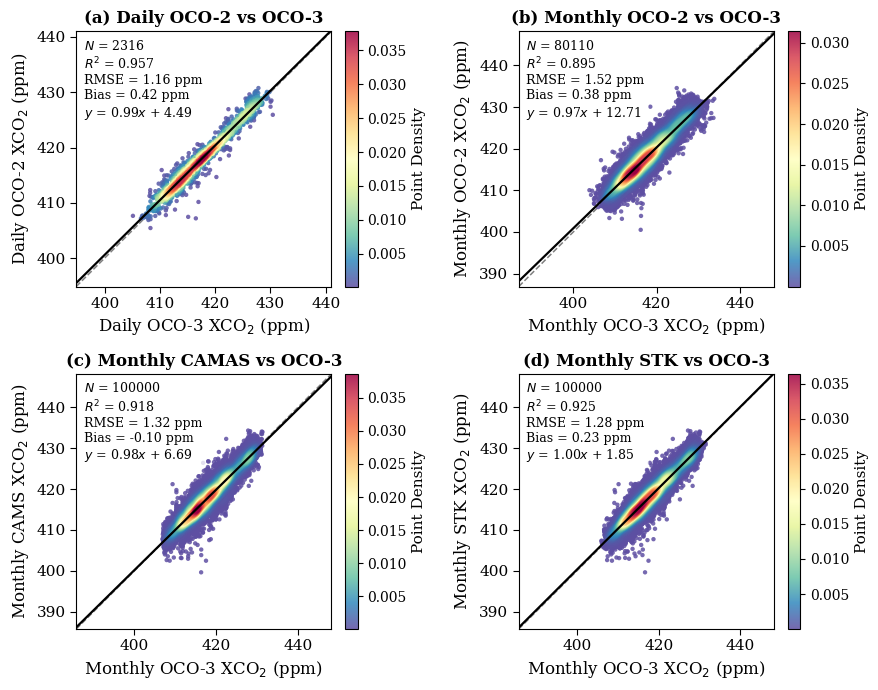

In [29]:
# Random sampling is applied when the number of matched samples is very large
# to reduce overplotting and improve plotting efficiency. A maximum of 30,000
# points is used for visualization, with a fixed random seed to ensure
# reproducibility.
fig, axes = plt.subplots(2, 2, figsize=(4.5*2, 3.5*2))

for i, match_name in enumerate(["daily", "month","cams","stk"]):
    if match_name == "stk":
        matched_csv = Validation_DIR / f"matched_stk_oco3.csv"
        ref_name = "stk"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)'
        y_label='Monthly STK XCO$_2$ (ppm)'
        title_name="Monthly STK vs OCO-3"
    elif match_name == "daily":
        matched_csv = Validation_DIR / f"matched_oco2_oco3_daily.csv"
        ref_name = "oco2"
        test_name="oco3"
        x_label='Daily OCO-3 XCO$_2$ (ppm)'
        y_label='Daily OCO-2 XCO$_2$ (ppm)'
        title_name="Daily OCO-2 vs OCO-3"
    elif match_name == "month":
        matched_csv = Validation_DIR / f"matched_oco2_oco3_month.csv"
        ref_name = "oco2"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)' # Capitalized 'Monthly' for consistency
        y_label='Monthly OCO-2 XCO$_2$ (ppm)'
        title_name="Monthly OCO-2 vs OCO-3"
    elif match_name == "cams":
        matched_csv = Validation_DIR / f"matched_cams_oco3_month.csv"
        ref_name = "cams"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)' # Capitalized 'Monthly' for consistency
        y_label='Monthly CAMS XCO$_2$ (ppm)'
        title_name="Monthly CAMAS vs OCO-3"
    df = pd.read_csv(matched_csv)
    sample_size = 100000

    if len(df) > sample_size:
        df_sampled = df.sample(n=sample_size, random_state=42)
    else:
        df_sampled = df

    print(f"Number of data points involved in plotting: {len(df_sampled)}")

    # 3. Assign the correct subplot from your 1x3 grid
    # Correctly index the 2D axes array
    row_idx = i // 2
    col_idx = i % 2
    ax = axes[row_idx, col_idx]

    sc, use_density = plot_density_scatter(
        ax=ax,
        df=df_sampled,
        x_name=ref_name,
        y_name=test_name,
        title_name=title_name,
        x_label=x_label,
        y_label=y_label,
        sublabel=chr(97+i),
        fontsize=12
    )

    if use_density and sc is not None:
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Point Density', fontsize=11)

plt.tight_layout()
png_fn = DOC_DIR / "validation_oco3_stk.png"
plt.savefig(png_fn, bbox_inches="tight")
print(f"Saved: {png_fn}")
plt.show()